# The Bessel family: values, gradients in x and in the order

chebax provides the cylindrical Bessel functions J, Y, I, K and the
spherical j, y for real order nu in [0, 10], as jax callables backed by
precomputed Chebyshev tables. Everything is jittable, vmappable, and
differentiable, including in the order nu, which is the part that has
been missing from the jax ecosystem (see jax#18119 for the request and
the Matern section at the end for why the nu gradient matters).

A recipe instance is created once (`chebax.besselj(2.5)`) and is then a
plain function of x. It is also a pytree, so it can be closed over,
passed as an argument to jitted functions, or stored in a model.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import chebax

## The four cylindrical functions

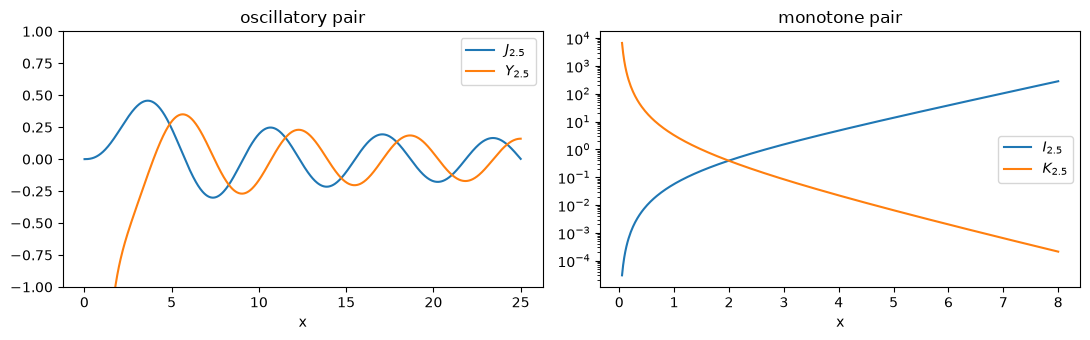

In [2]:
nu = 2.5
x = np.linspace(0.01, 25.0, 800)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(x, chebax.besselj(nu)(x), label=f"$J_{{{nu}}}$")
ax1.plot(x, chebax.bessely(nu)(x), label=f"$Y_{{{nu}}}$")
ax1.set_ylim(-1, 1)
ax1.set_xlabel("x")
ax1.legend()
ax1.set_title("oscillatory pair")

xs = np.linspace(0.05, 8.0, 400)
ax2.semilogy(xs, chebax.besseli(nu)(xs), label=f"$I_{{{nu}}}$")
ax2.semilogy(xs, chebax.besselk(nu)(xs), label=f"$K_{{{nu}}}$")
ax2.set_xlabel("x")
ax2.legend()
ax2.set_title("monotone pair")
plt.tight_layout()

## Agreement with scipy

scipy is an independent implementation (AMOS / cephes), so agreement to
near machine precision is a meaningful cross-check. The library's real
accuracy contract is against 40-digit mpmath references in the test
suite; this cell is just a quick sanity check you can rerun anywhere.

In [3]:
import scipy.special as sps

grid = np.linspace(0.1, 100.0, 500)
for name, ours, ref in [
    ("J", chebax.besselj(nu), sps.jv),
    ("Y", chebax.bessely(nu), sps.yv),
    ("I (scaled)", chebax.besseli(nu, scaled=True), sps.ive),
    ("K", chebax.besselk(nu), sps.kv),
]:
    a = np.asarray(ours(grid))
    b = ref(nu, grid)
    scale = np.max(np.abs(b))
    print(f"{name:11s} max abs diff vs scipy: {np.max(np.abs(a - b)):.2e}"
          f"  (values up to {scale:.2e})")

J           max abs diff vs scipy: 5.27e-15  (values up to 4.57e-01)
Y           max abs diff vs scipy: 1.14e-13  (values up to 7.58e+02)


I (scaled)  max abs diff vs scipy: 2.18e-15  (values up to 9.54e-02)
K           max abs diff vs scipy: 9.09e-13  (values up to 1.19e+03)


## Gradients in x

The instances are ordinary jax functions, so `jax.grad` just works. As a
check, the recurrence identity J'_nu = (J_{nu-1} - J_{nu+1}) / 2 holds to
rounding, with each side computed independently.

In [4]:
jv = chebax.besselj(nu)
dj = jax.vmap(jax.grad(jv))(jnp.asarray(grid))
identity = 0.5 * (chebax.besselj(nu - 1.0)(grid) - chebax.besselj(nu + 1.0)(grid))
print("max |J' - (J_{nu-1} - J_{nu+1})/2|:", float(jnp.max(jnp.abs(dj - identity))))

max |J' - (J_{nu-1} - J_{nu+1})/2|: 6.38378239159465e-16


## Gradients in the order nu

Two mechanisms, depending on the function:

- `besselk_fn(nu, x)` and `besseli_fn(nu, x)` take nu as a traced scalar,
  so `jax.grad` differentiates in nu directly.
- For J and Y the recurrence depth is structural in nu, so the order
  gradient ships as its own instance: `besselj_dnu(nu)`, `bessely_dnu(nu)`.

dK/dnu at (nu=2.5, x=3.0): grad 0.057784891133, central diff 0.057784891136


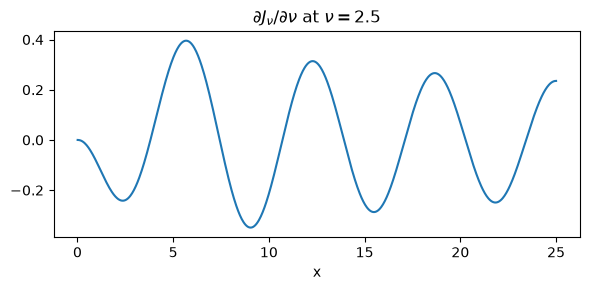

In [5]:
x0 = 3.0
g = jax.grad(chebax.besselk_fn, argnums=0)(nu, x0)
h = 1e-6
fd = (sps.kv(nu + h, x0) - sps.kv(nu - h, x0)) / (2 * h)
print(f"dK/dnu at (nu={nu}, x={x0}): grad {float(g):.12f}, central diff {fd:.12f}")

djdnu = chebax.besselj_dnu(nu)
plt.figure(figsize=(6, 3))
plt.plot(x, djdnu(x))
plt.xlabel("x")
plt.title(r"$\partial J_\nu / \partial \nu$ at $\nu = 2.5$")
plt.tight_layout()

## float32

Instances hold float64 tables, so a float32 input would silently promote.
`astype` gives a single-precision copy of the whole instance: the entire
computation then runs in float32, not just a downcast at the end.

In [6]:
jv32 = jv.astype(jnp.float32)
x32 = jnp.linspace(0.5, 20.0, 5, dtype=jnp.float32)
y32 = jv32(x32)
y64 = jv(x32.astype(jnp.float64))
print(y32.dtype, "  max diff vs float64:", float(jnp.max(jnp.abs(y32 - y64))))

float32   max diff vs float64: 4.325721139619709e-08


## Spherical Bessel functions

`spherical_jn(n)` and `spherical_yn(n)` for integer n in [0, 9] wrap the
half-integer cylindrical tables (the spherical half of jax#18119).

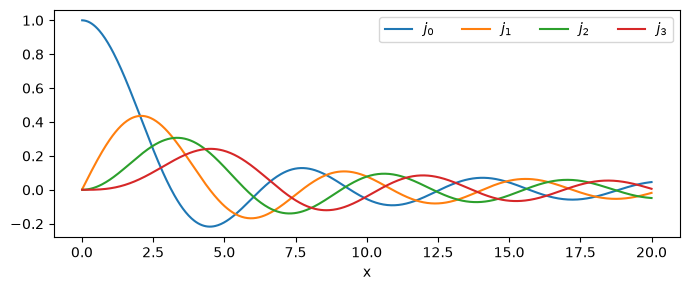

In [7]:
xg = np.linspace(0.01, 20.0, 600)
plt.figure(figsize=(7, 3))
for n in range(4):
    plt.plot(xg, chebax.spherical_jn(n)(xg), label=f"$j_{n}$")
plt.xlabel("x")
plt.legend(ncol=4)
plt.tight_layout()

## Use case: learning a Matern kernel's smoothness

The Matern covariance is

$$k(r) = \sigma^2 \, \frac{2^{1-\nu}}{\Gamma(\nu)} \, z^\nu K_\nu(z),
  \qquad z = \sqrt{2\nu}\, r / \ell$$

and learning nu by gradient descent needs dK_nu/dnu. `besselk_fn` takes
nu traced, so the whole kernel is differentiable in (nu, ell, sigma^2)
with plain `jax.grad`. Here we synthesize noiseless kernel values at
(nu=1.7, ell=0.9, sig2=1.3) and recover all three parameters with Adam
from a different starting point.

In [8]:
def matern(r, nu, ell, sig2):
    # r = 0 (every covariance diagonal) is exact via the select; masked
    # lanes see a safe dummy so log(0) cannot poison gradients
    rs = jnp.where(r > 0, r, 1.0)
    z = jnp.sqrt(2.0 * nu) * rs / ell
    log_c = (1.0 - nu) * jnp.log(2.0) - jax.scipy.special.gammaln(nu)
    k = sig2 * jnp.exp(log_c + nu * jnp.log(z)) * chebax.besselk_fn(nu, z)
    return jnp.where(r > 0, k, sig2)


r = jnp.linspace(0.05, 3.0, 25)
target = matern(r, nu=1.7, ell=0.9, sig2=1.3)


def loss(theta):
    nu_, log_ell, log_sig2 = theta
    k = matern(r, nu_, jnp.exp(log_ell), jnp.exp(log_sig2))
    return jnp.mean((jnp.log(k) - jnp.log(target)) ** 2)


grad = jax.jit(jax.grad(loss))
theta = jnp.array([1.0, 0.0, 0.0])  # start at nu=1, ell=1, sig2=1
m = v = jnp.zeros_like(theta)
lr, b1, b2, eps = 0.05, 0.9, 0.999, 1e-8
for i in range(600):
    g = grad(theta)
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g * g
    theta = theta - lr * (m / (1 - b1 ** (i + 1))) / (
        jnp.sqrt(v / (1 - b2 ** (i + 1))) + eps)

print(f"true:      nu=1.7,     ell=0.9,     sig2=1.3")
print(f"recovered: nu={float(theta[0]):.5f}, ell={float(jnp.exp(theta[1])):.5f}, "
      f"sig2={float(jnp.exp(theta[2])):.5f}")

true:      nu=1.7,     ell=0.9,     sig2=1.3
recovered: nu=1.70000, ell=0.90000, sig2=1.30000
